# DPT Bone Marrow (Subsampled) — λ_vf Sweep Plotting

Data extracted from the completed HPC run `dpt_bone_marrow_vf_sweep_20260524_135026`.  
All 5 seeds completed fully.  
Dataset: 2890 cells (subsampled). Root cell index: 1550.  
λ_lap fixed at 1. λ_vf swept over 6 values: `np.logspace(1.5, 4.0, 6)`.  
Epochs logged every 10 steps; epoch 140 used as proxy for epoch 150 (final).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# λ_vf values — np.logspace(1.5, 4.0, 6)
LAMBDA_VFS = np.logspace(1.5, 4.0, 6)
print('lambda_vf values:', np.round(LAMBDA_VFS, 4))

lambda_vf values: [   31.6228   100.       316.2278  1000.      3162.2777 10000.    ]


In [2]:
# ---------------------------------------------------------------------------
# Raw data: r values logged every 10 epochs (i=0,10,...,140)
# Shape: [seed, lambda_idx, epoch_idx]  where epoch_idx ∈ {0,...,14} → epochs 0,10,...,140
# All 5 seeds × 6 lambda values × 15 logged checkpoints — no missing data
# Run: dpt_bone_marrow_vf_sweep_20260524_135026  |  2890 cells (subsampled)
# ---------------------------------------------------------------------------

EPOCHS_LOGGED = list(range(0, 141, 10))  # 0, 10, ..., 140

# Each row = one lambda_vf, each column = one logged epoch
seed1 = np.array([
    # lv=31.62
    [0.561, 0.672, 0.619, 0.669, 0.687, 0.701, 0.713, 0.720, 0.726, 0.737, 0.750, 0.764, 0.777, 0.795, 0.814],
    # lv=100
    [0.565, 0.643, 0.659, 0.824, 0.779, 0.755, 0.725, 0.713, 0.706, 0.696, 0.680, 0.669, 0.661, 0.661, 0.674],
    # lv=316.2
    [0.448, 0.712, 0.821, 0.910, 0.906, 0.902, 0.910, 0.923, 0.922, 0.917, 0.887, 0.832, 0.756, 0.545, -0.037],
    # lv=1000
    [0.641, 0.637, 0.669, 0.684, 0.692, 0.686, 0.689, 0.695, 0.691, 0.530, 0.761, 0.532, 0.065, -0.051, -0.133],
    # lv=3162
    [0.442, 0.601, 0.318, 0.277, 0.260, -0.135, 0.065, -0.001, 0.023, 0.047, 0.046, 0.038, 0.034, 0.096, 0.051],
    # lv=10000
    [0.239, 0.373, 0.041, -0.028, -0.022, 0.008, -0.038, 0.002, -0.010, -0.053, -0.087, 0.149, 0.185, 0.119, 0.170],
])

seed2 = np.array([
    # lv=31.62
    [0.649, 0.621, 0.736, 0.746, 0.773, 0.766, 0.763, 0.749, 0.742, 0.738, 0.738, 0.736, 0.736, 0.739, 0.740],
    # lv=100
    [0.616, 0.617, 0.653, 0.677, 0.675, 0.668, 0.673, 0.677, 0.678, 0.692, 0.728, 0.386, 0.708, 0.316, 0.278],
    # lv=316.2
    [0.275, 0.711, 0.845, 0.858, 0.878, 0.911, 0.924, 0.925, 0.935, 0.924, 0.909, 0.892, 0.787, 0.432, 0.136],
    # lv=1000
    [0.420, 0.798, 0.783, 0.770, 0.788, 0.792, 0.797, 0.798, 0.798, 0.822, 0.046, 0.327, 0.094, 0.080, 0.094],
    # lv=3162
    [0.503, 0.539, 0.329, -0.042, 0.047, 0.063, -0.014, -0.081, -0.051, -0.020, -0.080, -0.080, -0.087, -0.096, -0.066],
    # lv=10000
    [0.387, 0.620, 0.378, 0.003, 0.213, 0.140, -0.003, 0.018, 0.072, 0.184, 0.138, 0.104, 0.114, 0.111, 0.138],
])

seed3 = np.array([
    # lv=31.62
    [0.294, 0.593, 0.800, 0.803, 0.806, 0.828, 0.839, 0.844, 0.841, 0.834, 0.830, 0.827, 0.826, 0.825, 0.824],
    # lv=100
    [0.664, 0.617, 0.807, 0.797, 0.817, 0.846, 0.883, 0.895, 0.902, 0.912, 0.917, 0.915, 0.909, 0.895, 0.883],
    # lv=316.2
    [0.633, 0.783, 0.863, 0.908, 0.858, 0.865, 0.877, -0.018, -0.062, 0.040, 0.080, -0.074, -0.130, 0.271, 0.085],
    # lv=1000
    [0.583, 0.204, 0.484, 0.662, 0.739, 0.756, 0.650, 0.474, 0.405, 0.393, 0.462, 0.616, 0.198, 0.033, 0.061],
    # lv=3162
    [0.247, 0.678, 0.293, 0.369, -0.127, -0.199, -0.215, -0.152, -0.100, -0.088, -0.105, -0.124, -0.140, -0.157, -0.096],
    # lv=10000
    [0.322, 0.027, 0.111, 0.039, 0.055, 0.055, 0.069, 0.049, 0.032, 0.057, 0.105, 0.122, 0.098, 0.117, 0.113],
])

seed4 = np.array([
    # lv=31.62
    [0.612, 0.887, 0.834, 0.820, 0.828, 0.838, 0.880, 0.902, 0.909, 0.915, 0.918, 0.921, 0.905, 0.883, 0.751],
    # lv=100
    [0.447, 0.734, 0.809, 0.903, 0.901, 0.908, 0.909, 0.904, 0.901, 0.896, 0.889, 0.883, 0.876, 0.870, 0.865],
    # lv=316.2
    [0.507, 0.717, 0.791, 0.846, 0.886, 0.906, 0.926, 0.906, 0.881, 0.857, 0.920, 0.696, 0.498, -0.096, 0.073],
    # lv=1000
    [0.613, 0.878, 0.403, 0.496, 0.733, 0.488, 0.046, 0.050, -0.138, -0.009, -0.195, 0.018, 0.012, -0.176, -0.186],
    # lv=3162
    [0.421, 0.715, 0.736, 0.705, 0.659, 0.050, 0.121, 0.081, 0.044, -0.032, 0.031, -0.002, -0.008, 0.002, -0.003],
    # lv=10000
    [0.451, 0.577, 0.437, 0.351, -0.090, -0.056, -0.009, -0.060, -0.018, -0.034, -0.053, -0.105, -0.126, -0.137, -0.119],
])

seed5 = np.array([
    # lv=31.62
    [0.394, 0.624, 0.716, 0.771, 0.812, 0.878, 0.912, 0.907, 0.904, 0.890, 0.878, 0.879, 0.873, 0.871, 0.863],
    # lv=100
    [-0.040, 0.140, 0.478, 0.559, 0.620, 0.685, 0.709, 0.729, 0.764, 0.791, 0.812, 0.817, 0.791, 0.716, 0.476],
    # lv=316.2
    [0.297, 0.658, 0.732, 0.630, 0.635, 0.637, 0.615, 0.566, 0.493, 0.459, 0.146, 0.005, 0.068, -0.073, -0.068],
    # lv=1000
    [0.491, 0.751, 0.766, 0.726, 0.905, 0.198, 0.049, 0.498, -0.072, -0.025, -0.016, -0.151, -0.040, -0.057, -0.085],
    # lv=3162
    [0.508, 0.714, 0.696, 0.470, -0.093, 0.008, 0.069, 0.096, -0.060, -0.076, -0.068, -0.054, -0.075, -0.097, -0.114],
    # lv=10000
    [0.457, 0.080, 0.048, -0.035, 0.024, 0.025, 0.040, 0.048, 0.039, 0.028, 0.070, 0.028, -0.024, -0.020, -0.010],
])

# Stack: shape (5, 6, 15)  — seeds × lambdas × logged_epochs
all_seeds = np.stack([seed1, seed2, seed3, seed4, seed5], axis=0)
print('all_seeds shape:', all_seeds.shape)  # (5, 6, 15)

all_seeds shape: (5, 6, 15)


In [3]:
# ---------------------------------------------------------------------------
# Summary: r at epoch ~50 (idx 5), ~100 (idx 10), ~140 (idx 14)
# Using logged epochs 50, 100, 140 as proxies for script checkpoints 50, 100, 150
# ---------------------------------------------------------------------------

EPOCH_IDX = {'~50': 5, '~100': 10, '~140': 14}

summary = {}
for label, eidx in EPOCH_IDX.items():
    vals = all_seeds[:, :, eidx]  # (5, 6)
    summary[label] = {
        'mean': np.nanmean(vals, axis=0),
        'std':  np.nanstd(vals, axis=0),
        'per_seed': vals,
    }

df_summary = pd.DataFrame({
    'lambda_vf': LAMBDA_VFS,
    'ep50_mean':  summary['~50']['mean'],
    'ep50_std':   summary['~50']['std'],
    'ep100_mean': summary['~100']['mean'],
    'ep100_std':  summary['~100']['std'],
    'ep140_mean': summary['~140']['mean'],
    'ep140_std':  summary['~140']['std'],
})
df_summary

,lambda_vf,ep50_mean,ep50_std,ep100_mean,ep100_std,ep140_mean,ep140_std
0,31.622777,0.8022,0.062040,0.8228,0.070218,0.7984,0.046323
1,100.000000,0.7724,0.092353,0.8052,0.090778,0.6352,0.231799
2,316.227766,0.8442,0.104868,0.5884,0.388868,0.0378,0.077329
3,1000.000000,0.5840,0.219756,0.2116,0.349024,-0.0498,0.109240
4,3162.277660,-0.0426,0.105152,-0.0352,0.061532,-0.0456,0.061288
5,10000.000000,0.0344,0.064083,0.0346,0.088726,0.0584,0.107630


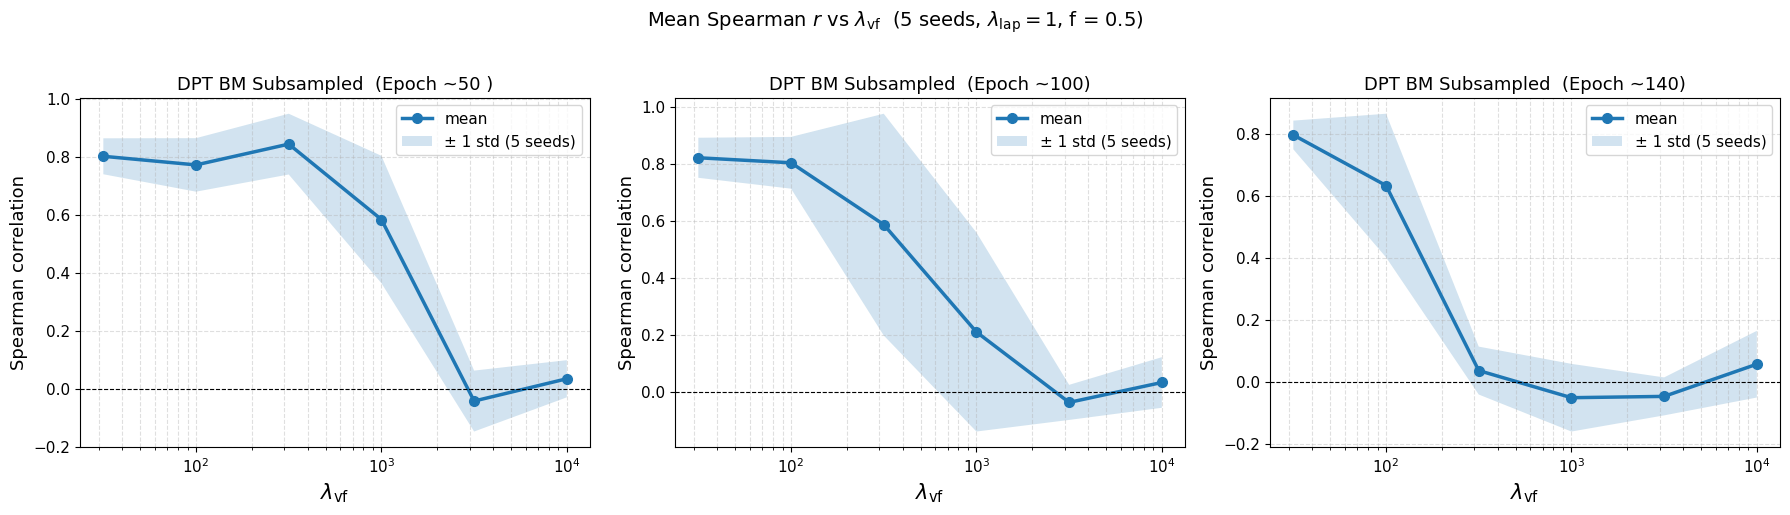

In [8]:
# ---------------------------------------------------------------------------
# Plot 1: Mean ± std across all 5 seeds — one panel per epoch checkpoint
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50 ',  axes[0]),
    ('~100', 'Epoch ~100',  axes[1]),
    ('~140', 'Epoch ~140',  axes[2]),
]

for label, title, ax in checkpoints:
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    line, = ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7, label='mean')
    band = ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2, label='± 1 std (5 seeds)')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
    ax.set_ylabel('Spearman correlation', fontsize=13)
    ax.set_title(f'DPT BM Subsampled  ({title})', fontsize=13)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)

plt.suptitle(
    r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (5 seeds, $\lambda_{\mathrm{lap}}=1$, f = 0.5)',
    fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_subsampled_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

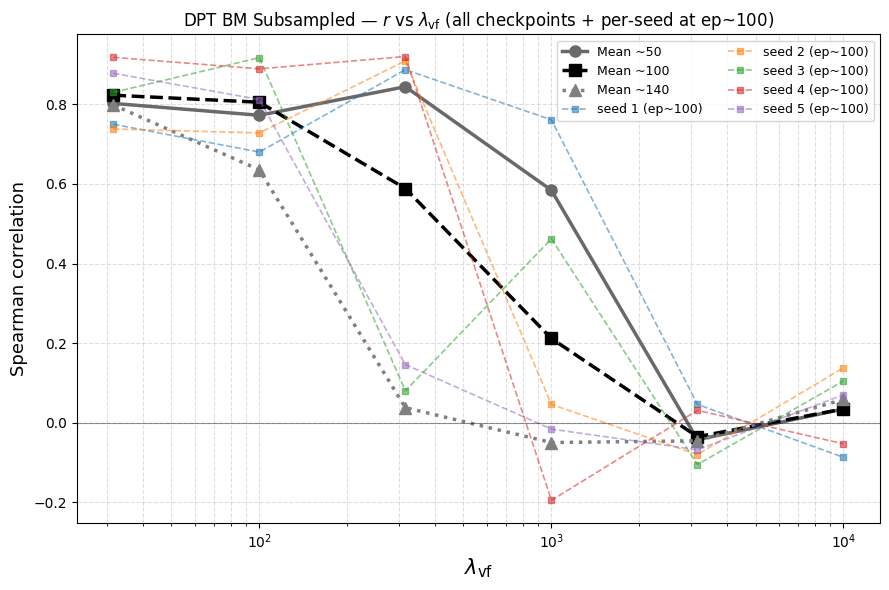

In [5]:
# ---------------------------------------------------------------------------
# Plot 2: Per-seed traces + mean — all three checkpoints overlaid
# ---------------------------------------------------------------------------

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
checkpoint_styles = {'~50': ('o', '-'), '~100': ('s', '--'), '~140': ('^', ':')}

fig, ax = plt.subplots(figsize=(9, 6))

grays = {'~50': 'dimgray', '~100': 'black', '~140': 'gray'}
for label, (marker, ls) in checkpoint_styles.items():
    mu = summary[label]['mean']
    ax.semilogx(LAMBDA_VFS, mu, marker=marker, linestyle=ls,
                linewidth=2.5, markersize=8, label=f'Mean {label}',
                color=grays[label])

# Individual seeds at epoch ~100
for s_idx, (color, slabel) in enumerate(zip(seed_colors, [f'seed {i}' for i in range(1, 6)])):
    vals = all_seeds[s_idx, :, EPOCH_IDX['~100']]
    ax.semilogx(LAMBDA_VFS, vals, marker='s', linestyle='--',
                linewidth=1.2, markersize=5, alpha=0.55, color=color, label=f'{slabel} (ep~100)')

ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title(r'DPT BM Subsampled — $r$ vs $\lambda_{\mathrm{vf}}$ (all checkpoints + per-seed at ep~100)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_subsampled_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

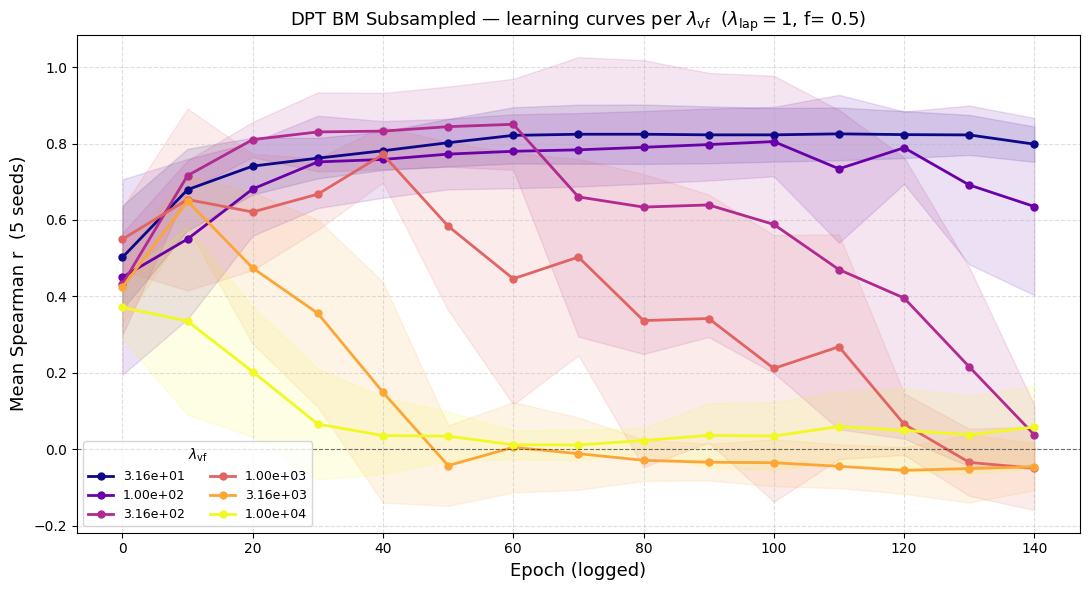

In [9]:
# ---------------------------------------------------------------------------
# Plot 3: Learning curves (r vs epoch) — mean across 5 seeds per λ_vf
# ---------------------------------------------------------------------------

epochs_arr = np.array(EPOCHS_LOGGED)
mean_curves = np.nanmean(all_seeds, axis=0)  # (6, 15)
std_curves  = np.nanstd(all_seeds, axis=0)

cmap = plt.cm.plasma
colors = [cmap(i / 5) for i in range(6)]

fig, ax = plt.subplots(figsize=(11, 6))
for lv_idx in range(6):
    lv_val = LAMBDA_VFS[lv_idx]
    mu = mean_curves[lv_idx]
    sig = std_curves[lv_idx]
    ax.plot(epochs_arr, mu, marker='o', markersize=5, linewidth=2.0,
            color=colors[lv_idx], label=f'{lv_val:.2e}')
    ax.fill_between(epochs_arr, mu - sig, mu + sig, alpha=0.12, color=colors[lv_idx])

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch (logged)', fontsize=13)
ax.set_ylabel('Mean Spearman r  (5 seeds)', fontsize=13)
ax.set_title(r'DPT BM Subsampled — learning curves per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$, f= 0.5)', fontsize=13)
ax.legend(title=r'$\lambda_{\mathrm{vf}}$', fontsize=9, ncol=2,
          loc='lower left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_subsampled_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Plot 4: Per-seed learning curves (small multiples) for each λ_vf
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
seed_labels = [f'seed {i}' for i in range(1, 6)]

for lv_idx, ax in enumerate(axes.flat):
    lv_val = LAMBDA_VFS[lv_idx]
    for s_idx in range(5):
        ax.plot(epochs_arr, all_seeds[s_idx, lv_idx, :],
                marker='o', markersize=3, linewidth=1.5,
                color=seed_colors[s_idx], label=seed_labels[s_idx], alpha=0.8)
    # Mean
    ax.plot(epochs_arr, mean_curves[lv_idx],
            color='black', linewidth=2.5, linestyle='--', label='mean')
    ax.axhline(0, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(rf'$\lambda_{{vf}}={lv_val:.2e}$', fontsize=11)
    ax.set_ylim(-0.35, 1.0)
    ax.grid(True, linestyle='--', alpha=0.3)
    if lv_idx in (0, 3):
        ax.set_ylabel('Spearman r', fontsize=10)
    if lv_idx >= 3:
        ax.set_xlabel('Epoch', fontsize=10)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    r'DPT BM Subsampled — per-seed learning curves for each $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vf_sweep_subsampled_per_seed_grid.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Plot 5: Heatmap — r at epoch ~100 for all seeds × all λ_vf
# ---------------------------------------------------------------------------

r_ep100 = all_seeds[:, :, EPOCH_IDX['~100']]  # (5, 6)

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(r_ep100, aspect='auto', cmap='RdYlGn', vmin=-0.3, vmax=1.0)
ax.set_xticks(range(6))
ax.set_xticklabels([f'{v:.2e}' for v in LAMBDA_VFS], rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels([f'seed {i}' for i in range(1, 6)])
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=12)
ax.set_title('Spearman r at epoch ~100  (subsampled, 2890 cells)', fontsize=12)
plt.colorbar(im, ax=ax, label='Spearman r')

for i in range(5):
    for j in range(6):
        val = r_ep100[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                color='black' if abs(val) < 0.7 else 'white')

plt.tight_layout()
plt.savefig('vf_sweep_subsampled_heatmap_ep100.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Plot 6: Peak r achieved per (seed, lambda_vf) — shows best attainable r
# ---------------------------------------------------------------------------

peak_r = np.nanmax(all_seeds, axis=2)  # (5, 6) — max over epochs
mean_peak = peak_r.mean(axis=0)
std_peak  = peak_r.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(LAMBDA_VFS, mean_peak, marker='o', linewidth=2.5, markersize=8,
            color='tab:blue', label='mean peak r')
ax.fill_between(LAMBDA_VFS, mean_peak - std_peak, mean_peak + std_peak,
                alpha=0.2, color='tab:blue')

for s_idx, (color, slabel) in enumerate(zip(seed_colors, seed_labels)):
    ax.semilogx(LAMBDA_VFS, peak_r[s_idx], marker='x', linestyle=':',
                linewidth=1.0, markersize=6, alpha=0.6, color=color, label=slabel)

ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Peak Spearman r (best epoch)', fontsize=13)
ax.set_title(r'DPT BM Subsampled — peak $r$ per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('vf_sweep_subsampled_peak_r.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Summary table — best λ_vf per checkpoint + peak r
# ---------------------------------------------------------------------------

print('Best lambda_vf by mean r (5 seeds):\n')
for label in ['~50', '~100', '~140']:
    mu = summary[label]['mean']
    best_idx = np.nanargmax(mu)
    print(f'  Epoch {label:5s}:  lambda_vf = {LAMBDA_VFS[best_idx]:.3e}  '
          f'→  mean r = {mu[best_idx]:.3f}  (std={summary[label]["std"][best_idx]:.3f})')

print()
best_peak_idx = np.argmax(mean_peak)
print(f'  Peak r:     lambda_vf = {LAMBDA_VFS[best_peak_idx]:.3e}  '
      f'→  mean peak r = {mean_peak[best_peak_idx]:.3f}  (std={std_peak[best_peak_idx]:.3f})')

print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))